In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import utils
import os
import matplotlib.pyplot as plt
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

figures_dir = "../figures/"

## Regions of Interest

In [2]:
# Regions of interest (permanently shadowed regions)
regions_psr_df = pd.read_excel("../data/permanently-shadowed-regions.xlsx")
lats_psr = regions_psr_df["Cent. Lat."].values
lons_psr = regions_psr_df["Cent. Long."].values - 180
areas_psr = regions_psr_df["Area (km2)"].values
coverage_psr = regions_psr_df["Coverage (%)"].values
alts_psr = np.zeros_like(lats_psr)
regions_psr_df.head()

,PSR ID,Cent. Lat.,Cent. Long.,Area (km2),Perimeter (km),Features of Interest,Lunar Features,Coverage (%),Data Quality
0,SP_896450_1282030,-89.645,128.203,233.698,70.32,"2012-258 (M1102304370R): 129.549, -89.632 (S80...",Shackleton Crater,65,1.0
1,SP_895060_2806850,-89.506,280.685,53.262,45.48,NaN,de Gerlache Crater Shackleton Crater,0,NaN
2,SP_890390_3377770,-89.039,337.777,60.358,54.24,NaN,Haworth Crater Shackleton Crater,0,NaN
3,SP_889970_3170870,-88.997,317.087,44.284,49.56,NaN,de Gerlache Crater Haworth Crater,0,NaN
4,SP_889970_0191990,-88.997,19.199,55.408,36.84,NaN,Haworth Crater Shackleton Crater,10,1.0


In [3]:
# Regions of interest (impact craters)
regions_ic_df = pd.read_excel(
    "../data/Lunar_Impact_Crater_Database_v08Sep2015.xls", sheet_name="Database"
)
regions_ic_df = regions_ic_df[regions_ic_df["3. Latitude [°]"] <= 90]
lats_ic = regions_ic_df["3. Latitude [°]"].values
lons_ic = regions_ic_df["4. Longitude [°]"].values
areas_ic = np.pi * np.square(regions_ic_df["6. Radius [km]"].values)
alts_ic = np.zeros_like(lats_ic)
regions_ic_df.head()

,1. Crater name,2. Diameter [km],3. Latitude [°],4. Longitude [°],5. East longitude [°],6. Radius [km],7. Radius [m],8. Apparent diameter [km],9. Transient cavity diameter [km],10. Transient cavity diameter [km],...,73. Average CF [μm],74. Average OMAT,75. Average FeO [wt.-%],76. OMAT range,77. Plg abundance class,78. Province,79. Peak degradation,80. PAN location,81. Rays,1. Crater name .1
0,Abbe,63.98,-57.58,174.77,174.77,31.990,31990.0,55.0228,51.469659,37.371461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe
1,Abbe H,25.13,-58.44,177.58,177.58,12.565,12565.0,21.6118,23.258264,15.604124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe H
2,Abbe K,26.10,-59.82,176.86,176.86,13.050,13050.0,22.4460,24.019177,16.166327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe K
3,Abbe M,28.61,-61.75,175.24,175.24,14.305,14305.0,24.6046,25.968919,17.614889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe M
4,Abbot,10.40,5.56,54.74,54.74,5.200,5200.0,8.6320,8.736000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbot


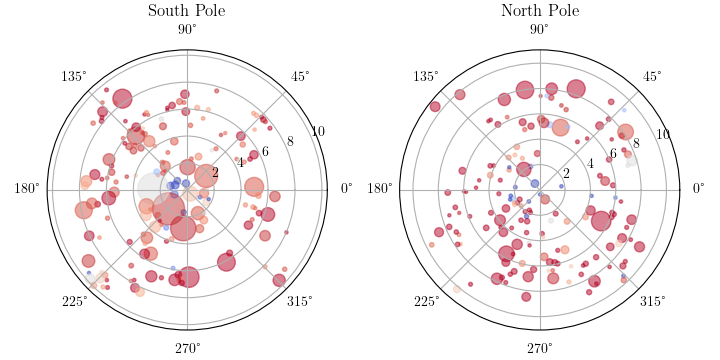

In [4]:
plot_scale = 0.5
fig_scale = 0.02

fig = plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
# Polar plot (South pole)
ax = fig.add_subplot(121, polar=True)
idxs = lats_psr < 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 + lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("South Pole")

# Polar plot (North pole)
ax = fig.add_subplot(122, polar=True)
idxs = lats_psr > 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 - lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("North Pole")
plt.savefig(figures_dir + "psr.pdf")
plt.tight_layout()
plt.show()

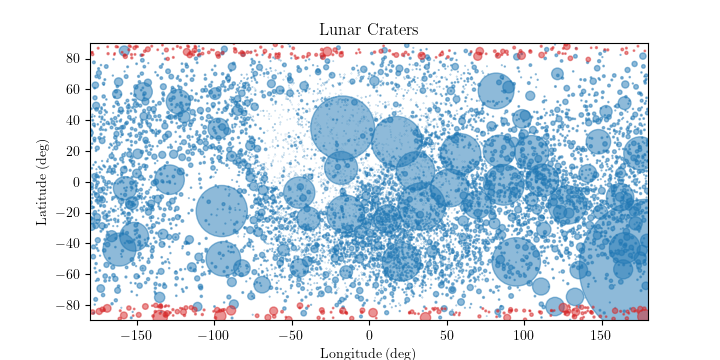

In [5]:
plot_scale = 0.002
fig_scale = 0.02
plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
plt.scatter(lons_ic, lats_ic, s=areas_ic * plot_scale, alpha=0.5, c="tab:blue")
plt.scatter(
    lons_psr,
    lats_psr,
    c="tab:red",
    s=areas_psr * plot_scale * 50,
    alpha=0.5,
)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Lunar Craters")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
p1 = plt.Circle((0, 0), 90, color="tab:blue", alpha=0.5)
p2 = plt.Circle((0, 0), 90, color="tab:red", alpha=0.5)
plt.legend(
    [p1, p2],
    ["Impact Craters", "Permanently Shadowed Regions"],
    loc="center left",
    ncol=2,
    bbox_to_anchor=(0.1, -0.25),
)
plt.savefig(figures_dir + "craters.pdf")
plt.show()

In [6]:
lats = np.concatenate([lats_ic, lats_psr])
lons = np.concatenate([lons_ic, lons_psr])
alts = np.concatenate([alts_ic, alts_psr])

# Satellite (Long Term)

In [7]:
# Epoch
epoch_0 = pnt.SpiceInterface.string_to_tai("2026/1/01 00:00:00.000 UTC")

# Orbital elements
sma = 5740  # [km]  a, Semi-major axis
ecc = 0.58  # [-]   e, Eccentricity
inc = np.deg2rad(54.856)  # [rad] i, Inclination
raan = np.deg2rad(0)  # [rad] W, Right ascension of the ascending node
aop = np.deg2rad(86.322)  # [rad] w, Argument of periapsis
ma = np.deg2rad(0)  # [rad] M, Mean anomaly
coe_sat_OP = np.array([sma, ecc, inc, raan, aop, ma])
rv0_sat_OP = pnt.classical_to_cartesian(coe_sat_OP, pnt.MU_MOON)
rv0_sat_mi = pnt.FrameConverter.convert(epoch_0, rv0_sat_OP,pnt.MOON_OP, pnt.MOON_CI)

# Time
T = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)
Dt = 5 * pnt.SECS_PER_MINUTE
dt = 5 * pnt.SECS_PER_MINUTE
tf = 1 * T
N_t = int(tf / Dt)
tspan = np.linspace(0, tf, N_t)
epochs = epoch_0 + tspan

# Dynamics
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


In [8]:
coe_sat_OP

array([5.74000000e+03, 5.80000000e-01, 9.57417814e-01, 0.00000000e+00,
       1.50660312e+00, 0.00000000e+00])

In [9]:
coe_sat_OP

array([5.74000000e+03, 5.80000000e-01, 9.57417814e-01, 0.00000000e+00,
       1.50660312e+00, 0.00000000e+00])

In [10]:
# Propagation
rv_moon_sat_mi = dynamics.propagate(rv0_sat_mi, epoch_0, epochs)
rv_earth_sat_eci = pnt.FrameConverter.convert(epochs, rv_moon_sat_mi, pnt.MOON_CI, pnt.ECI)
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.EARTH)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.SUN)

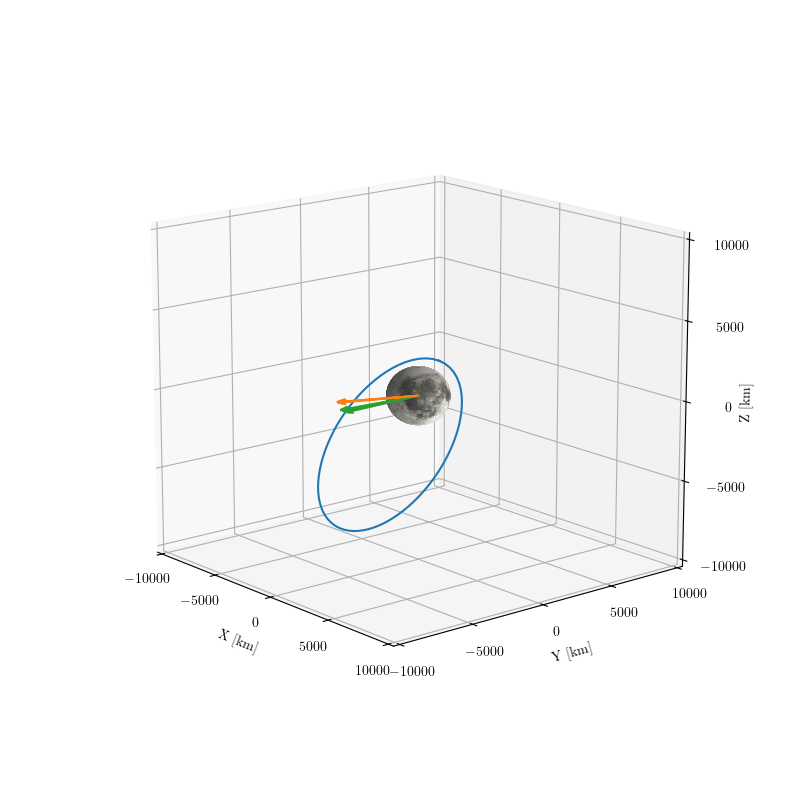

In [11]:
rv_moon_sat_op = pnt.FrameConverter.convert(epochs, rv_moon_sat_mi, pnt.MOON_CI,pnt.MOON_OP)
rv_moon_earth_op = pnt.FrameConverter.convert(epochs, rv_moon_earth_mi, pnt.MOON_CI,pnt.MOON_OP)
rv_moon_sun_op = pnt.FrameConverter.convert(epochs, rv_moon_sun_mi, pnt.MOON_CI,pnt.MOON_OP)

# Satellite orbit in OP frame
fig = pnt.plots.Plot3D(figsize=(8, 8), elev=15, azim=-40)
fig.plot_surface(pnt.MOON, scale=3)
fig.label_axis()
fig.plot(rv_moon_sat_op[:, 0:3], label="Satellite", color="tab:blue", mask=False)

# Earth and Sun positions
for i in range(0, N_t, 40):
    earth_dir = rv_moon_earth_op[i, 0:3]
    earth_dir = earth_dir / np.linalg.norm(earth_dir) * 3 * pnt.R_MOON
    sun_dir = rv_moon_sun_op[i, 0:3]
    sun_dir = sun_dir / np.linalg.norm(sun_dir) * 3 * pnt.R_MOON
    org = np.zeros(3)
    fig.ax.quiver(
        *org, *earth_dir, color="tab:green", label="Earth", arrow_length_ratio=0.1
    )
    fig.ax.quiver(
        *org, *sun_dir, color="tab:orange", label="Sun", arrow_length_ratio=0.1
    )

# Change z-axis label margin
fig.ax.zaxis.labelpad = 5
# plt.savefig("figures/obs_locations.pdf")
plt.show()

In [12]:
print(coe_sat_OP)

[5.74000000e+03 5.80000000e-01 9.57417814e-01 0.00000000e+00
 1.50660312e+00 0.00000000e+00]


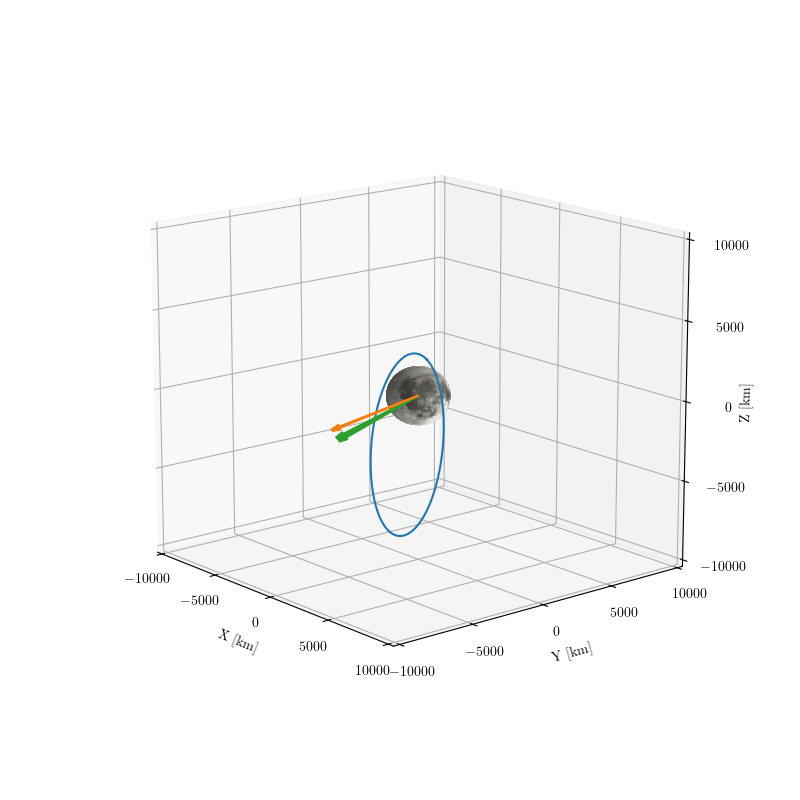

In [13]:
# Satellite orbit in MI frame
fig = pnt.plots.Plot3D(figsize=(8, 8), elev=15, azim=-40)
fig.plot_surface(pnt.MOON, scale=3)
fig.label_axis()
fig.plot(rv_moon_sat_mi[:, 0:3], label="Satellite", color="tab:blue", mask=False)

# Earth and Sun positions
for i in range(0, N_t, 40):
    earth_dir = rv_moon_earth_mi[i, 0:3]
    earth_dir = earth_dir / np.linalg.norm(earth_dir) * 3 * pnt.R_MOON
    sun_dir = rv_moon_sun_mi[i, 0:3]
    sun_dir = sun_dir / np.linalg.norm(sun_dir) * 3 * pnt.R_MOON
    org = np.zeros(3)
    fig.ax.quiver(
        *org, *earth_dir, color="tab:green", label="Earth", arrow_length_ratio=0.1
    )
    fig.ax.quiver(
        *org, *sun_dir, color="tab:orange", label="Sun", arrow_length_ratio=0.1
    )

# Change z-axis label margin
fig.ax.zaxis.labelpad = 5
# plt.savefig("figures/obs_locations.pdf")
plt.show()

In [14]:
# Locations
N_loc = 10
np.random.seed(0)
idxs_south_pole = np.where(lats < -60)[0]
idxs = np.random.choice(idxs_south_pole, N_loc)
loc_lats = np.deg2rad(lats[idxs])
loc_lons = np.deg2rad(lons[idxs])
loc_alts = alts[idxs]

r_obs_pa = pnt.geographical_to_cartesian(
    np.vstack((loc_lats, loc_lons, loc_alts)).T, pnt.R_MOON
)
rv_obs_pa = np.hstack((r_obs_pa, np.zeros((N_loc, 3))))
rv_obs_mi = pnt.FrameConverter.convert(epoch_0, rv_obs_pa, pnt.MOON_PA, pnt.MOON_CI)

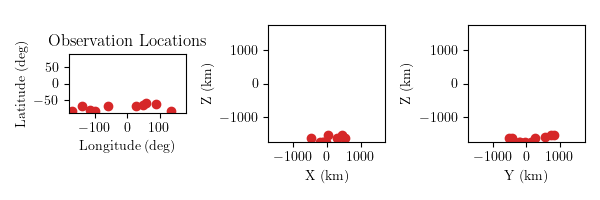

In [15]:
# Lat-lon and position in PA frame
plt.figure(figsize=(6, 2))
plt.subplot(131)
plt.plot(np.rad2deg(loc_lons), np.rad2deg(loc_lats), "o", color="tab:red")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Observation Locations")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(132)
plt.plot(r_obs_pa[:, 0], r_obs_pa[:, 2], "o", color="tab:red")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(133)
plt.plot(r_obs_pa[:, 1], r_obs_pa[:, 2], "o", color="tab:red")
plt.xlabel("Y (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

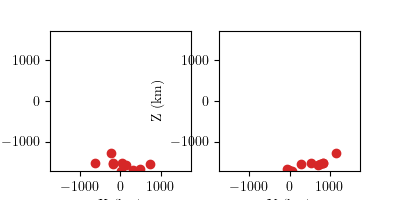

In [16]:
# Position in MI frame
plt.figure(figsize=(4, 2))
plt.subplot(121)
plt.plot(rv_obs_mi[:, 0], rv_obs_mi[:, 2], "o", color="tab:red")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(122)
plt.plot(rv_obs_mi[:, 1], rv_obs_mi[:, 2], "o", color="tab:red")
plt.xlabel("Y (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.show()

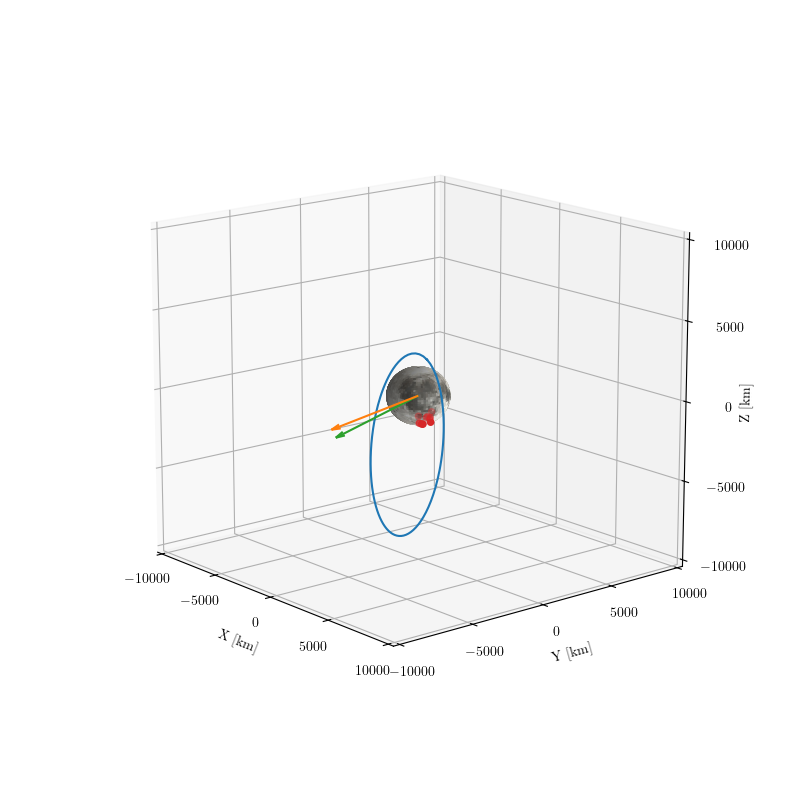

In [17]:
# Satellite orbit in MI frame
fig = pnt.plots.Plot3D(figsize=(8, 8), elev=15, azim=-40)
fig.plot_surface(pnt.MOON, scale=3)
fig.label_axis()
fig.plot(rv_moon_sat_mi[:, 0:3], label="Satellite", color="tab:blue", mask=False)
fig.scatter(
    rv_obs_mi[:, 0:3], label="Observation Locations", color="tab:red", mask=False
)

# Earth and Sun positions
earth_dir = rv_moon_earth_mi[0, 0:3]
earth_dir = earth_dir / np.linalg.norm(earth_dir) * 3 * pnt.R_MOON
sun_dir = rv_moon_sun_mi[0, 0:3]
sun_dir = sun_dir / np.linalg.norm(sun_dir) * 3 * pnt.R_MOON
org = np.zeros(3)
fig.ax.quiver(
    *org, *earth_dir, color="tab:green", label="Earth", arrow_length_ratio=0.1
)
fig.ax.quiver(*org, *sun_dir, color="tab:orange", label="Sun", arrow_length_ratio=0.1)

# Change z-axis label margin
fig.ax.zaxis.labelpad = 5
plt.savefig(figures_dir + "obs_locations.pdf")
plt.show()

# Attitude

In [18]:
r_sun = rv_moon_sun_mi[:, 0:3] - rv_moon_sat_mi[:, 0:3]
r_earth = rv_moon_earth_mi[:, 0:3] - rv_moon_sat_mi[:, 0:3]

e_sun = r_sun / np.linalg.norm(r_sun, axis=1)[:, None]
e_earth = r_earth / np.linalg.norm(r_earth, axis=1)[:, None]

r = rv_moon_sat_mi[:, 0:3]
v = rv_moon_sat_mi[:, 3:6]
r_norm = r / np.linalg.norm(r, axis=1)[:, None]
v_norm = v / np.linalg.norm(v, axis=1)[:, None]
e_nadir = -r_norm


def cross_norm(a, b):
    return np.cross(a, b) / np.linalg.norm(np.cross(a, b), axis=1)[:, None]


# Ideally
#    ex = e_sun
#    ey = e_earth or -e_y = e_earth
#    ez = e_nadir

# Standard frames
# - Radial, Tangential and Normal (RTN) frame
er = r_norm
en = cross_norm(r, v)
et = cross_norm(en, er)

# - Yaw-Steering (YS)
ez_ys = -r_norm
ey_ys = cross_norm(e_nadir, e_sun)
ex_ys = cross_norm(ey_ys, ez_ys)

# - Orbit-Normal (ON)
ex_on = et
ey_on = -en
ez_on = -er

# - Sun-Pointing (SP)
ex_sp = e_sun
ey_sp = cross_norm(e_nadir, e_sun)
ez_sp = cross_norm(ex_sp, ey_sp)

# By preference
from collections import defaultdict

frames = defaultdict(dict)


def safe_acos(x):
    return np.arccos(np.clip(x, -1, 1))


# - Sun-Nadir
ex_sn = e_sun
ey_sn = cross_norm(e_nadir, e_sun)
ez_sn = cross_norm(ex_sn, ey_sn)
sun_sn = np.rad2deg(safe_acos(np.sum(e_sun * ex_sn, axis=1)))
earth_sn = np.rad2deg(safe_acos(np.sum(e_earth * ey_sn, axis=1)))
nadir_sn = np.rad2deg(safe_acos(np.sum(e_nadir * ez_sn, axis=1)))
frames["Sun"]["Nadir"] = {
    "ex": ex_sn,
    "ey": ey_sn,
    "ez": ez_sn,
    "Sun": sun_sn,
    "Earth": earth_sn,
    "Nadir": nadir_sn,
}

# - Sun-Earth
ex_se = e_sun
ez_se = cross_norm(e_sun, e_earth)
ey_se = cross_norm(ez_se, ex_se)
sun_se = np.rad2deg(safe_acos(np.sum(e_sun * ex_se, axis=1)))
earth_se = np.rad2deg(safe_acos(np.sum(e_earth * ey_se, axis=1)))
nadir_se = np.rad2deg(safe_acos(np.sum(e_nadir * ez_se, axis=1)))
frames["Sun"]["Earth"] = {
    "ex": ex_se,
    "ey": ey_se,
    "ez": ez_se,
    "Sun": sun_se,
    "Earth": earth_se,
    "Nadir": nadir_se,
}

# - Nadir-Sun
ez_ns = e_nadir
ey_ns = cross_norm(e_nadir, e_sun)
ex_ns = cross_norm(ey_ns, ez_ns)
sun_ns = np.rad2deg(safe_acos(np.sum(e_sun * ex_ns, axis=1)))
earth_ns = np.rad2deg(safe_acos(np.sum(e_earth * ey_ns, axis=1)))
nadir_ns = np.rad2deg(safe_acos(np.sum(e_nadir * ez_ns, axis=1)))
frames["Nadir"]["Sun"] = {
    "ex": ex_ns,
    "ey": ey_ns,
    "ez": ez_ns,
    "Sun": sun_ns,
    "Earth": earth_ns,
    "Nadir": nadir_ns,
}

# - Nadir-Earth
ez_ne = e_nadir
ex_ne = cross_norm(e_earth, e_nadir)
ey_ne = cross_norm(ez_ne, ex_ne)
sun_ne = np.rad2deg(safe_acos(np.sum(e_sun * ex_ne, axis=1)))
earth_ne = np.rad2deg(safe_acos(np.sum(e_earth * ey_ne, axis=1)))
nadir_ne = np.rad2deg(safe_acos(np.sum(e_nadir * ez_ne, axis=1)))
frames["Nadir"]["Earth"] = {
    "ex": ex_ne,
    "ey": ey_ne,
    "ez": ez_ne,
    "Sun": sun_ne,
    "Earth": earth_ne,
    "Nadir": nadir_ne,
}

# - Earth-Sun
ey_es = e_earth
ez_es = cross_norm(e_sun, e_earth)
ex_es = cross_norm(ey_es, ez_es)
sun_es = np.rad2deg(safe_acos(np.sum(e_sun * ex_es, axis=1)))
earth_es = np.rad2deg(safe_acos(np.sum(e_earth * ey_es, axis=1)))
nadir_es = np.rad2deg(safe_acos(np.sum(e_nadir * ez_es, axis=1)))
frames["Earth"]["Sun"] = {
    "ex": ex_es,
    "ey": ey_es,
    "ez": ez_es,
    "Sun": sun_es,
    "Earth": earth_es,
    "Nadir": nadir_es,
}

# - Earth-Nadir (EN)
ey_en = e_earth
ez_en = cross_norm(e_nadir, e_earth)
ex_en = cross_norm(ey_en, ez_en)
sun_en = np.rad2deg(safe_acos(np.sum(e_sun * ex_en, axis=1)))
earth_en = np.rad2deg(safe_acos(np.sum(e_earth * ey_en, axis=1)))
nadir_en = np.rad2deg(safe_acos(np.sum(e_nadir * ez_en, axis=1)))
frames["Earth"]["Nadir"] = {
    "ex": ex_en,
    "ey": ey_en,
    "ez": ez_en,
    "Sun": sun_en,
    "Earth": earth_en,
    "Nadir": nadir_en,
}

In [19]:
# Plot a table with the frames and mean of "sun", "earth" and "nadir" angles
dfs = {}
pointings = ["Sun", "Earth", "Nadir"]
for p1 in pointings:
    dfs[p1] = pd.DataFrame(
        {
            p2: {p3: frames[p2][p3][p1].mean() for p3 in pointings if p3 != p2}
            for p2 in pointings
        }
    )
    print(p1)
    print(dfs[p1])
    print()

Sun
                Sun      Earth      Nadir
Earth  3.103999e-07        NaN  86.327452
Nadir  3.103999e-07  87.552303        NaN
Sun             NaN  82.385536  22.940561

Earth
             Sun         Earth      Nadir
Earth  82.385536           NaN  25.680590
Nadir  86.423737  3.403508e-07        NaN
Sun          NaN  3.403508e-07  86.423737

Nadir
             Sun      Earth         Nadir
Earth  59.767826        NaN  3.403508e-07
Nadir  22.940561  90.000000           NaN
Sun          NaN  59.767826  3.403508e-07



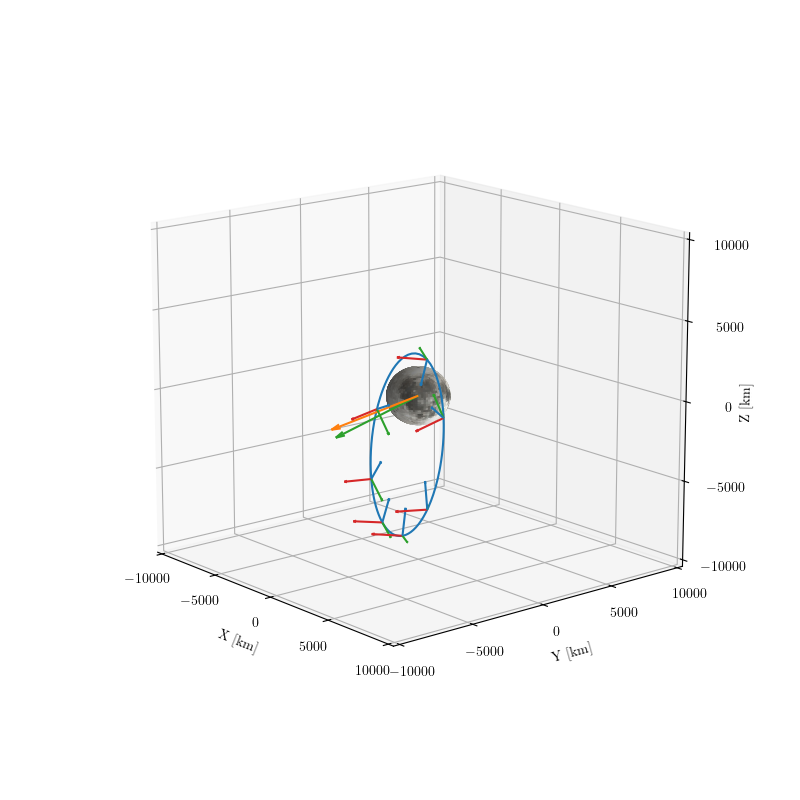

In [20]:
# Satellite orbit in MI frame
fig = pnt.plots.Plot3D(figsize=(8, 8), elev=15, azim=-40)
fig.plot_surface(pnt.MOON, scale=3)
fig.label_axis()
fig.plot(rv_moon_sat_mi[:, 0:3], label="Satellite", color="tab:blue", mask=False)

# Earth and Sun positions
earth_dir = rv_moon_earth_mi[0, 0:3]
earth_dir = earth_dir / np.linalg.norm(earth_dir) * 3 * pnt.R_MOON
sun_dir = rv_moon_sun_mi[0, 0:3]
sun_dir = sun_dir / np.linalg.norm(sun_dir) * 3 * pnt.R_MOON
org = np.zeros(3)
fig.ax.quiver(
    *org, *earth_dir, color="tab:green", label="Earth", arrow_length_ratio=0.1
)
fig.ax.quiver(*org, *sun_dir, color="tab:orange", label="Sun", arrow_length_ratio=0.1)

# Yaw-Steering Frame
for i in range(0, N_t, 20):
    r_ys = rv_moon_sat_mi[i, 0:3]
    fig.ax.quiver(
        *r_ys,
        *ex_ys[i] * pnt.R_MOON,
        color="tab:red",
        label="X_ys",
        arrow_length_ratio=0.1
    )
    fig.ax.quiver(
        *r_ys,
        *ey_ys[i] * pnt.R_MOON,
        color="tab:green",
        label="Y_ys",
        arrow_length_ratio=0.1
    )
    fig.ax.quiver(
        *r_ys,
        *ez_ys[i] * pnt.R_MOON,
        color="tab:blue",
        label="Z_ys",
        arrow_length_ratio=0.1
    )

# Change z-axis label margin
fig.ax.zaxis.labelpad = 5
plt.show()

# Moon Locations

In [21]:
rv_loc_sat_mi = np.zeros((N_loc, N_t, 6))
az_el_rho = np.zeros((N_loc, N_t, 3))
for i in range(N_loc):
    rv_loc_sat_mi[i, :, :] = rv_moon_sat_mi - rv_obs_mi[i, :]
    az_el_rho[i, :, :] = pnt.cartesian_to_azimuth_elevation_range(
        rv_obs_mi[i, :3], rv_moon_sat_mi[:, :3]
    )

In [22]:
# Max elevation for each location
max_elevation = np.max(az_el_rho[:, :, 1], axis=1)
min_elev = np.deg2rad(10)
min_elevevation = np.maximum(min_elev, max_elevation - np.deg2rad(10))
print("Max elevation (geometry)   ", np.rad2deg(max_elevation).round(0))
print("Min elevation (requirement)", np.rad2deg(min_elevevation).round(0))

user_visible = np.greater_equal(az_el_rho[:, :, 1], min_elevevation[:, None])
print(user_visible.shape)

Max elevation (geometry)    [51. 51. 78. 60. 68. 78. 47. 77. 37. 54.]
Min elevation (requirement) [41. 41. 68. 50. 58. 68. 37. 67. 27. 44.]
(10, 130)


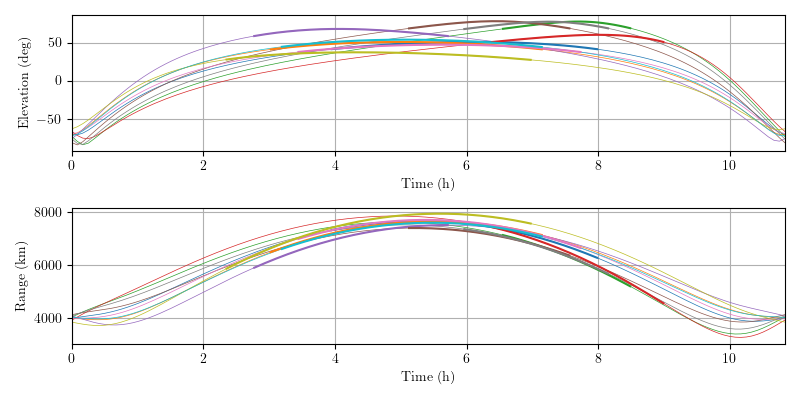

In [23]:
# Elevation and range over time
plt.figure(figsize=(8, 4))
x = tspan / pnt.SECS_PER_HOUR
x_lim = (0, tspan[-1] / pnt.SECS_PER_HOUR)

plt.subplot(211)
el = np.rad2deg(az_el_rho[:, :, 1].copy())
plt.plot(x, el.T, label="Elevation", lw=0.5)
el[~user_visible] = np.nan
plt.plot(x, el.T, lw=1.5)
plt.xlabel("Time (h)")
plt.ylabel("Elevation (deg)")
plt.xlim(x_lim)
plt.grid()
plt.subplot(212)
rho = az_el_rho[:, :, 2].copy()
plt.plot(x, rho.T, label="Range", lw=0.5)
rho[~user_visible] = np.nan
plt.plot(x, rho.T, lw=1.5)
plt.xlabel("Time (h)")
plt.ylabel("Range (km)")
plt.xlim(x_lim)
plt.grid()
plt.tight_layout()
plt.show()

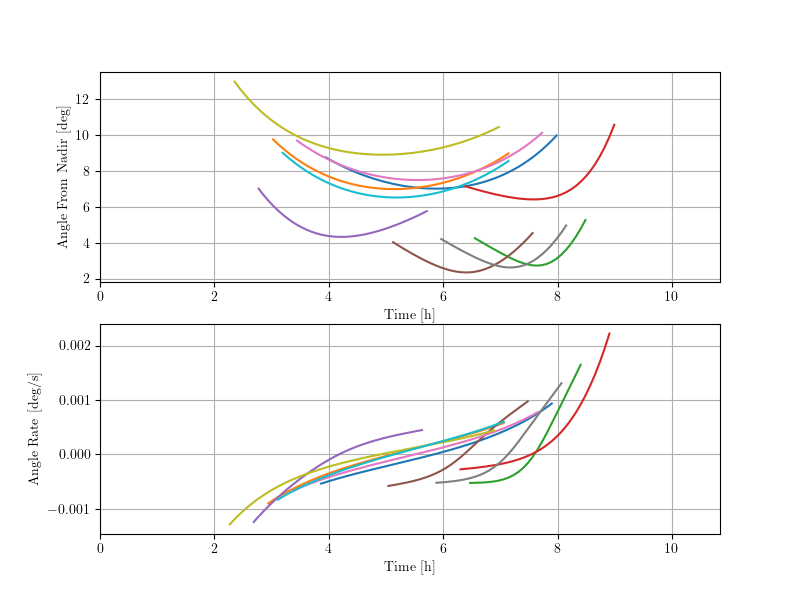

In [24]:
# Angles from nadir of the different users
e_user = (
    -rv_loc_sat_mi[:, :, :3]
    / np.linalg.norm(rv_loc_sat_mi[:, :, :3], axis=2)[:, :, None]
)
angle_nadir_user = np.rad2deg(safe_acos(np.sum(e_user * e_nadir, axis=2)))

plt.figure(figsize=(8, 6))
x = tspan / pnt.SECS_PER_HOUR
x_lim = (0, tspan[-1] / pnt.SECS_PER_HOUR)

plt.subplot(211)
y = angle_nadir_user.copy()
y[~user_visible] = np.nan
plt.plot(x, y.T)
plt.xlabel("Time [h]")
plt.ylabel("Angle From Nadir [deg]")
plt.xlim(x_lim)
plt.grid()

plt.subplot(212)
y = np.diff(angle_nadir_user, axis=1) / Dt
y[~user_visible[:, 1:]] = np.nan
plt.plot(x[:-1], y.T)
plt.xlabel("Time [h]")
plt.ylabel("Angle Rate [deg/s]")
plt.xlim(x_lim)
plt.grid()

# Navigation

In [25]:
user = 0
r = rv_loc_sat_mi[user, :, :3].copy()

In [26]:
start, end = utils.get_start_and_end_indexes(user_visible[0])
start, end

AttributeError: module 'utils' has no attribute 'get_start_and_end_indexes'

In [ ]:
# User Case #1 – Surface Landers
# EIRP between 21.5 and 26.5 dBW, and G/T between -19.2 and -11.5dB/K

# 1.1 Low Lunar Orbit (LLO) mission
# - Several short duration contacts to transfer commands and telemetry
# - Scheduled access
# - Omnidirectional low gain antennas
orbital_user = {
    "altitude": 100,  # [km]
    "duration": 30,  # [days]
    "EIRP": 9,  # [dBW]
    "GT": -23.4,  # [dB/K]
    "data": 500,  # [Mb] per day
    "dara_rate": 123,  # [kbps]
}

# 1.2 Surface operations
# - Long duration contacts to relay commands, telemetry and payload data.
# - Steerable high gain antenna
surface_user = {
    "location": (-90, 0),  # [deg]
    "duration": 13,  # [days]
    "EIRP": 21.5,  # [dBW]
    "GT": -19.2,  # [dB/K]
    "data": 60e3,  # [Mb] per day
    "contact": 467,  # [min] per day
    "data_rate": 1966,  # [kbps]
}

# User Case #2 - Autonomous Rover
autonomous_user = {
    "location": (-74.5, 135),  # [deg]
    "duration": 13,  # [days]
    "EIRP": 13,  # [dBW]
    "GT": -23,  # [dB/K]
    "data": 20e3,  # [Mb] per day
    "contact": 529,  # [min] per day
    "data_rate": 492,  # [kbps]
}

# User Case #3 - Tele-Operated Rover
teleop_user = {
    "location": (-90, 0),  # [deg]
    "duration": 100,  # [days]
    "EIRP": 26.5,  # [dBW]
    "GT": -6,  # [dB/K]
    "data": 30e3,  # [Mb] per day
    "contact": 248,  # [min] per day
    "data_rate": 1966,  # [kbps]
}

# User Case #4 - CubeSat
cubesat_user = {
    "altitude": 100,  # [km]
    "duration": 181,  # [days]
    "EIRP": 5.7,  # [dBW]
    "GT": -23.4,  # [dB/K]
    "data": 500,  # [Mb] per day
    "contact": 100,  # [min] per day
    "data_rate": 61,  # [kbps]
}

# User Case #5 - Lander on the North Pole
north_pole_user = {
    "location": (90, 0),  # [deg]
    "duration": 13,  # [days]
    "EIRP": 21.5,  # [dBW]
    "GT": -19.2,  # [dB/K]
    "data": 3e3,  # [Mb] per day
    "contact": 23,  # [min] per day
    "data_rate": 1966,  # [kbps]
}

In [31]:
# Navigation signal
fs = 2492.028e6  # Carrier frequency [Hz]
fc = 5.115e6  # Spread code frequency [Hz]
Tc = 1 / fc  # Spread code period [s]

# Receiver parameters
NF_lna = 1  # LNA noise figure [dB]
T_sys = 113  # System noise temperature [K]
B_dll = 0.5  # DLL bandwidth [Hz]
d = 1.0  # Early-late spacing [chips]
T_i = 0.02  # Coherent integration time [s]
B_fe = 2 * fc  # Front-end bandwidth [Hz]

# Constants
c = 2.998e8  # Speed of light [m/s]
k = -228.6  # Boltzmann constant [dBW/Hz/K]

# Link budget
# r = np.linalg.norm(rv_loc_sat_mi[:, :, :3], axis=2) * 1e3  # Distance [m]
# r[~user_visible] = np.nan
r = 8e6 # Distance [m]
EIRP = 30  # Equivalent isotropic radiated power [dBW]
L_fs = pnt.decimal2dB((4 * np.pi * r * fs / c) ** 2)  # Free space loss [dB]
L_fs = 10 * np.log10((4 * np.pi * r * fs / c) ** 2)  # Free space loss [dB]
Pr = EIRP - L_fs  # Received power [dBW]

# Antenna gain
T_atm = 290  # Atmospheric noise temperature [K]
T_eq = 10 * np.log10(
    T_sys + T_atm * (10 ** (NF_lna / 10) - 1)
)  # Equivalent noise temperature [dBK]

mu = 0.6  # Antenna efficiency
D_ant = 0.3  # Antenna diameter [m]
# Maximum antenna gain [dBi]
Gr_max = pnt.decimal2dB(mu * (np.pi * D_ant * fs / c) ** 2)
Gr_max = 6

theta = 0  # Beamwidth [deg]
theta_3dB = 40  # 3 dB beamwidth [deg]
Gr = pnt.decimal2dB(pnt.dB2decimal(Gr_max) - 12 * (theta / theta_3dB) ** 2)  # [dBi]

# Gain-to-noise temperature [dB]
GT = Gr - T_eq  
# GT = -20 
CN0 = Pr - k + GT  # Carrier-to-noise density ratio [dB-Hz]

# Error contributions
# Delay Lock Loop (DLL) error [m]
term_1 = (c * Tc) ** 2 * (B_dll * (1 - 0.5 * B_dll * T_i)) / (2 * CN0)
if d >= np.pi / (Tc * B_fe):
    sigma_p_dll_sq = term_1 * d
elif np.pi / (Tc * B_fe) > d > 1 / (Tc * B_fe):
    term_2 = (1 / (Tc * B_fe)) + ((Tc * B_fe) / (np.pi - 1)) * (
        d - (1 / (Tc * B_fe))
    ) ** 2
    term_3 = 1 + (2 / (T_i * CN0 * (2 - d)))
    sigma_p_dll_sq = term_1 * term_2 * term_3
else:  # d <= 1 / (T_c * B_fe)
    term_2 = 1 / (Tc * B_fe)
    term_3 = 1 + (1 / (T_i * CN0))
    sigma_p_dll_sq = term_1 * term_2 * term_3
sigma_p_dll = np.sqrt(sigma_p_dll_sq)

sigma_p_eph = 5  # Satellite ephemeris error [m]
sigma_p_rel = 0.31  # Residual relay delay error [m]
sigma_p_mul = 0.2  # Lunar multipath error [m]
sigma_p_non_eph = np.sqrt(sigma_p_dll**2 + sigma_p_rel**2 + sigma_p_mul**2)
sigma_p_tot = np.sqrt(4 * sigma_p_eph**2 + sigma_p_non_eph**2)

In [35]:
CN0

63.41595778181656

In [34]:
BW = 3.5e6 # [Hz]


In [30]:

# Data rate
# Pre-coded GMSK BTs = 0.25 on the Lunar Pathfinder S-band link
Rcs = 4096  # Coded symbol rate [kbps]
Rd = 2702 # Data rate [kbps]
BW = 0.86 * Rcs
SNR = CN0 - 10 * np.log10(BW)  # Signal-to-noise ratio [dB]


63.41595778181656

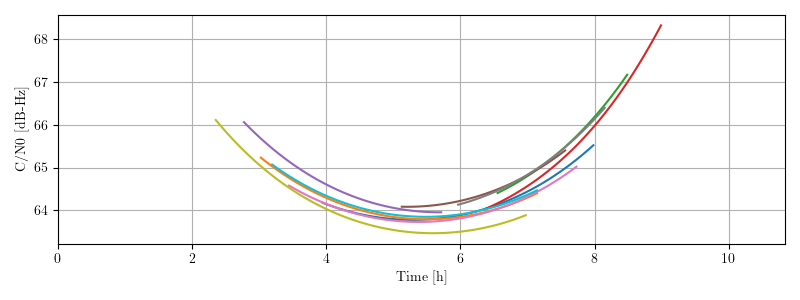

In [ ]:
plt.figure(figsize=(8, 3))
x = tspan / pnt.SECS_PER_HOUR
x_lim = (0, tspan[-1] / pnt.SECS_PER_HOUR)
plt.plot(x, CN0.T)
plt.xlabel("Time [h]")
plt.ylabel("C/N0 [dB-Hz]")
plt.xlim(x_lim)
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# GDOP
w = 50
s = 47
e = s + w
e_usr_sat = utils.normalize(rv_loc_sat_mi[user, s:e, :3])
# G = np.hstack((e_usr_sat, np.ones((e_usr_sat.shape[0], 1))))
G = e_usr_sat
H = np.linalg.inv(G.T @ G)
gdop = np.sqrt(np.trace(H))
print(f"Duration {w * Dt / pnt.SECS_PER_HOUR:.2f} h")
print("PDOP", gdop)

Duration 4.17 h
PDOP 14.068778264400626


# Earth Ground Stations

In [ ]:
# Earth ground stations (Pathfinder document)
use_dsn = True

earth_dns_loc = np.array(
    [
        # Madrid Deep Space Communications Complex (40°25′26″N 4°15′16″W)
        [pnt.dms2degrees([40, 25, 26]), pnt.dms2degrees([4, 15, 16]), 0],
        # Goldstone Deep Space Communications Complex (35°25′36″N 116°52′58″W)
        [pnt.dms2degrees([35, 25, 36]), -pnt.dms2degrees([116, 52, 58]), 0],
        # Canberra Deep Space Communication Complex (35°24′07″S 148°58′30″E)
        [-pnt.dms2degrees([35, 24, 7]), pnt.dms2degrees([148, 58, 30]), 0],
    ]
)
earth_gs_loc = np.array(
    [
        # Goonhilly Earth Station (50°02′53″N 5°10′55″W)
        [pnt.dms2degrees([50, 2, 53]), -pnt.dms2degrees([5, 10, 55]), 0],
        # Indian Deep Space Network (12°54′06″N 77°22′05″E)
        [pnt.dms2degrees([12, 54, 6]), pnt.dms2degrees([77, 22, 5]), 0],
    ]
)
gs_names = ["Goonhilly", "Indian DSN"]
if use_dsn:
    earth_gs_loc = np.vstack((earth_gs_loc, earth_dns_loc))
    gs_names += ["Madrid DSN", "Goldstone DSN", "Canberra DSN"]

# Earth ground stations in MI frame
N_gs = len(earth_gs_loc)
earth_gs_loc[:, :2] = np.deg2rad(earth_gs_loc[:, :2])
r_earth_gs_ecef = pnt.geographical_to_cartesian(earth_gs_loc, pnt.R_EARTH)
rv_earth_gs_ecef = np.hstack((r_earth_gs_ecef, np.zeros((N_gs, 3))))
rv_earth_gs_eci = np.zeros((N_gs, N_t, 6))
rv_earth_gs_mi = np.zeros((N_gs, N_t, 6))
for i in range(N_gs):
    rv_earth_gs_eci[i, :, :] = pnt.FrameConverter.convert(
        epoch_0 + tspan, rv_earth_gs_ecef[i, :], pnt.ECEF, pnt.ECI
    )
    rv_earth_gs_mi[i, :, :] = pnt.FrameConverter.convert(
        epoch_0 + tspan, rv_earth_gs_eci[i, :, :], pnt.ECI, pnt.MOON_CI
    )

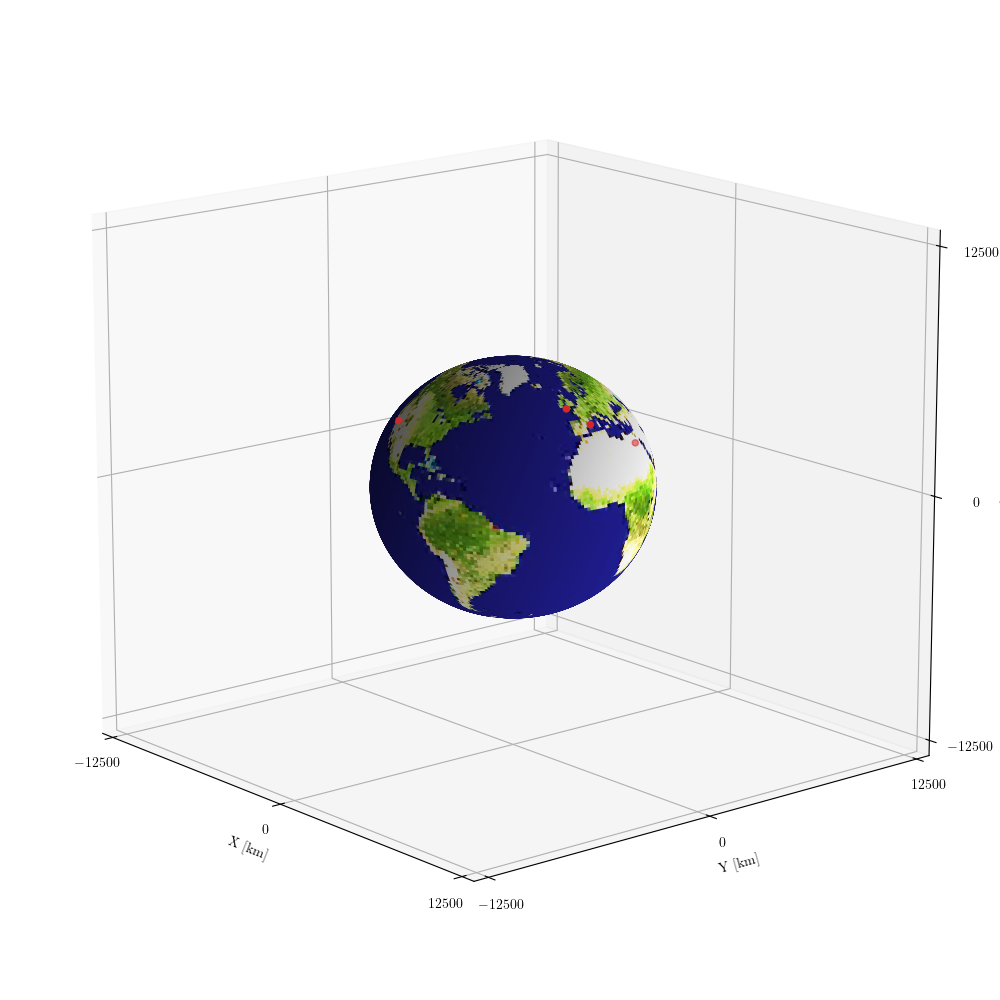

In [ ]:
# Plot Earth ground stations
fig = pnt.plots.Plot3D(figsize=(10, 10), elev=15, azim=-40)
fig.plot_surface(pnt.EARTH, scale=1)
fig.label_axis()
fig.scatter(
    r_earth_gs_ecef[:, 0:3], label="Earth Ground Stations", color="tab:red", mask=False
)
fig.ax.set_xlim(-2 * pnt.R_EARTH, 2 * pnt.R_EARTH)
fig.ax.set_ylim(-2 * pnt.R_EARTH, 2 * pnt.R_EARTH)
fig.ax.set_zlim(-2 * pnt.R_EARTH, 2 * pnt.R_EARTH)
# fig.ax.zaxis.labelpad = 5
plt.tight_layout()
plt.savefig(figures_dir + "Earth_gs.pdf")
plt.show()

In [ ]:
# Earth and moon occultation
bodies = [pnt.EARTH]
radii = pnt.R_EARTH
idxs_occult = np.zeros((N_gs, N_t), dtype=bool)
for i_gs in range(N_gs):
    idxs_occult[i_gs, :] = np.less_equal(
        pnt.compute_occultation(
            epoch_0 + tspan,
            rv_earth_gs_mi[i_gs, :, 0:3],
            rv_moon_sat_mi[:, 0:3],
            pnt.MOON_CI,
            pnt.MOON_CI,
            bodies,
        ),
        radii * (1 - 1e-6),
    ).flatten()

# Elevation and range over time
az_el_rho_gs = np.zeros((N_gs, N_t, 3))
idxs_elev = np.zeros((N_gs, N_t), dtype=bool)
min_elev = np.deg2rad(10)
for i_gs in range(N_gs):
    az_el_rho_gs[i_gs, :, :] = pnt.cartesian_to_azimuth_elevation_range(
        rv_earth_gs_eci[i_gs, :, 0:3], rv_earth_sat_eci[:, 0:3]
    )
    idxs_elev[i_gs, :] = np.greater_equal(az_el_rho_gs[i_gs, :, 1], min_elev)

# Visibility
idxs_visible = ~idxs_occult & idxs_elev
min_duration = int(10 * pnt.SECS_PER_MINUTE / Dt)

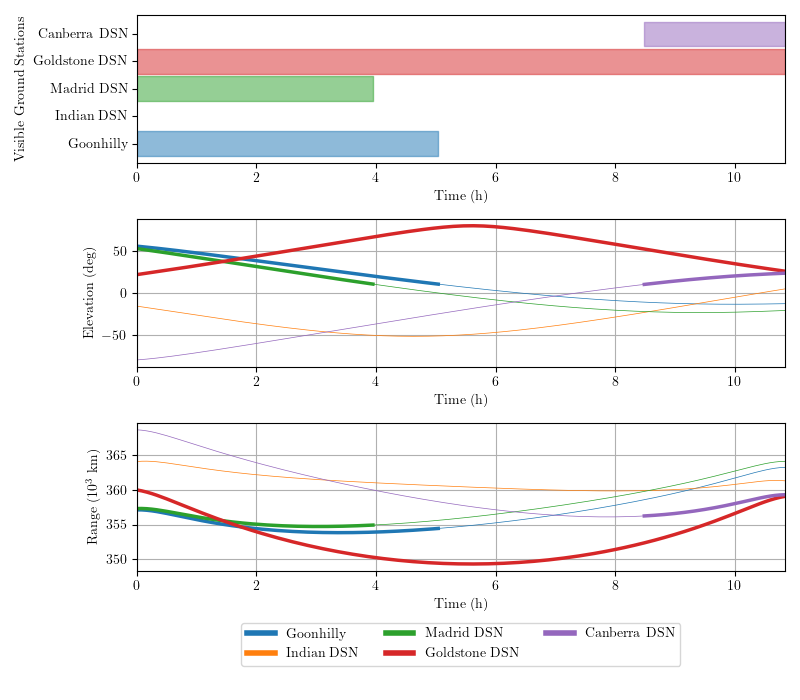

In [ ]:
# Plot visibility, elevation, and range
plt.figure(figsize=(8, 7))
x = tspan / pnt.SECS_PER_HOUR

# Plot visibility
plt.subplot(311)
for i_gs in range(N_gs):
    tstarts, tends = utils.get_start_and_end_indexes(idxs_visible[i_gs])
    for ts, te in zip(tstarts, tends):
        if te - ts < min_duration:
            print(f"{gs_names[i_gs]} visible from {ts} to {te}")
        plt.fill_between(
            x[ts:te], i_gs - 0.45, i_gs + 0.45, color=pnt.plots.COLORS[i_gs], alpha=0.5
        )

plt.xlabel("Time (h)")
plt.ylabel("Visible Ground Stations")
plt.xlim(x_lim)
plt.yticks(range(N_gs), gs_names)
plt.tight_layout()

# Plot elevation
plt.subplot(312)
for i_gs in range(N_gs):
    el = np.rad2deg(az_el_rho_gs[i_gs, :, 1].copy())
    plt.plot(x, el, label=gs_names[i_gs], lw=0.5, color=pnt.plots.COLORS[i_gs])
    el[~idxs_visible[i_gs]] = np.nan
    plt.plot(x, el, lw=2.5, color=pnt.plots.COLORS[i_gs])
plt.xlabel("Time (h)")
plt.ylabel("Elevation (deg)")
plt.xlim(x_lim)
plt.grid()

# Plot range
plt.subplot(313)
for i_gs in range(N_gs):
    rho = az_el_rho_gs[i_gs, :, 2].copy() / 1e3
    plt.plot(x, rho, label=gs_names[i_gs], lw=0.5, color=pnt.plots.COLORS[i_gs])
    rho[~idxs_visible[i_gs]] = np.nan
    plt.plot(x, rho, lw=2.5, color=pnt.plots.COLORS[i_gs])
plt.xlabel("Time (h)")
plt.ylabel("Range ($10^3$ km)")
plt.xlim(x_lim)
plt.grid()

# Legend
legend_lines = [
    plt.Line2D([0], [0], color=pnt.plots.COLORS[i], lw=4, label=gs_names[i])
    for i in range(N_gs)
]
plt.legend(
    handles=legend_lines,
    loc="center",
    ncol=N_gs // 2 + 1,
    bbox_to_anchor=(0.5, -0.5),
)
plt.tight_layout()
plt.show()

# Sun Visibility

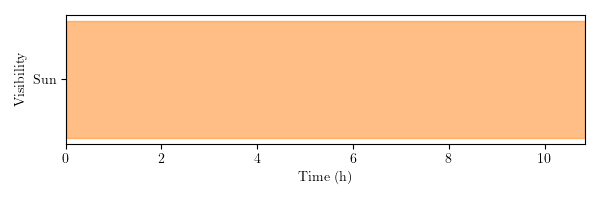

In [ ]:
# Sun visibility
bodies = [pnt.EARTH, pnt.MOON]
radii = np.array([pnt.R_EARTH, pnt.R_MOON])
idxs_occult_sun = np.less_equal(
    pnt.compute_occultation(
        epoch_0 + tspan,
        rv_moon_sun_mi[:, 0:3],
        rv_moon_sat_mi[:, 0:3],
        pnt.MOON_CI,
        pnt.MOON_CI,
        bodies,
    ),
    radii * 1.1,
)

# Sun visibility
idxs_visible_sun = ~idxs_occult_sun.any(axis=1)

# Plot visibility
plt.figure(figsize=(6, 2))
x = tspan / pnt.SECS_PER_HOUR
plt.fill_between(x, -0.5, 0.5, where=idxs_visible_sun, color="tab:orange", alpha=0.5)
plt.xlabel("Time (h)")
plt.ylabel("Visibility")
plt.xlim(x_lim)
plt.yticks([0], ["Sun"])
plt.tight_layout()
plt.show()

# Link Budgets